### Import Library

Pada tahap ini, dilakukan impor berbagai library yang digunakan untuk mendukung proses pengolahan citra digital, ekstraksi fitur tekstur, visualisasi data, preprocessing data, serta pembangunan dan evaluasi model klasifikasi. Berikut merupakan penjelasan fungsi dari masing-masing library yang digunakan dalam penelitian ini.

| No | Library                                    | Fungsi                                                                                                                                                                                                    |
| -- | ------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | `os`                                       | Digunakan untuk berinteraksi dengan sistem operasi, seperti mengakses direktori, membaca struktur folder dataset, dan mengelola file citra.                                                               |
| 2  | `cv2` (`cv`)                               | Library OpenCV yang digunakan untuk membaca, memproses, memanipulasi, dan melakukan transformasi pada citra digital, seperti resize, konversi grayscale, filtering, dan operasi pengolahan citra lainnya. |
| 3  | `zipfile`                                  | Digunakan untuk mengekstrak dataset yang masih tersimpan dalam format `.zip` sehingga dapat digunakan pada proses analisis.                                                                               |
| 4  | `numpy` (`np`)                             | Digunakan untuk operasi komputasi numerik dan manipulasi array multidimensi yang menjadi dasar dalam pengolahan citra digital dan perhitungan matematis.                                                  |
| 5  | `pandas` (`pd`)                            | Digunakan untuk mengelola dan menganalisis data dalam bentuk tabel atau `DataFrame`, seperti menyimpan hasil ekstraksi fitur dan hasil evaluasi model.                                                    |
| 6  | `matplotlib.pyplot` (`plt`)                | Digunakan untuk membuat visualisasi data, seperti menampilkan sampel citra, distribusi data, dan confusion matrix hasil klasifikasi.                                                                      |
| 7  | `skimage.feature.graycomatrix`             | Digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) yang merepresentasikan hubungan tingkat keabuan antar piksel pada citra.                                                                 |
| 8  | `skimage.feature.graycoprops`              | Digunakan untuk menghitung karakteristik tekstur dari matriks GLCM, seperti contrast, dissimilarity, homogeneity, energy, correlation, dan ASM.                                                           |
| 9  | `sklearn.model_selection.train_test_split` | Digunakan untuk membagi dataset menjadi data pelatihan (training set) dan data pengujian (testing set).                                                                                                   |
| 10 | `sklearn.preprocessing.LabelEncoder`       | Digunakan untuk mengubah label kelas yang berbentuk teks menjadi representasi numerik sehingga dapat diproses oleh algoritma machine learning.                                                            |
| 11 | `sklearn.preprocessing.StandardScaler`     | Digunakan untuk melakukan normalisasi data fitur sehingga setiap fitur memiliki skala yang seragam dan tidak mendominasi fitur lainnya.                                                                   |
| 12 | `sklearn.metrics.accuracy_score`           | Digunakan untuk menghitung tingkat akurasi model klasifikasi berdasarkan jumlah prediksi yang benar terhadap seluruh data uji.                                                                            |
| 13 | `sklearn.metrics.classification_report`    | Digunakan untuk menghasilkan laporan evaluasi model yang berisi nilai precision, recall, f1-score, dan support pada setiap kelas.                                                                         |
| 14 | `sklearn.metrics.confusion_matrix`         | Digunakan untuk menampilkan matriks evaluasi yang menunjukkan jumlah prediksi benar dan salah pada setiap kelas.                                                                                          |
| 15 | `sklearn.metrics.precision_score`          | Digunakan untuk mengukur tingkat ketepatan model dalam memberikan prediksi pada masing-masing kelas.                                                                                                      |
| 16 | `sklearn.metrics.recall_score`             | Digunakan untuk mengukur kemampuan model dalam mendeteksi seluruh data yang benar pada setiap kelas.                                                                                                      |
| 17 | `sklearn.metrics.f1_score`                 | Digunakan untuk menghitung rata-rata harmonis antara nilai precision dan recall sehingga memberikan gambaran performa model secara lebih seimbang.                                                        |
| 18 | `sklearn.svm.SVC`                          | Implementasi algoritma Support Vector Machine (SVM) yang digunakan untuk melakukan klasifikasi dengan mencari hyperplane optimal sebagai pemisah antar kelas.                                             |
| 19 | `sklearn.ensemble.RandomForestClassifier`  | Implementasi algoritma Random Forest yang memanfaatkan kumpulan decision tree untuk meningkatkan kemampuan generalisasi dan akurasi prediksi.                                                             |
| 20 | `sklearn.neighbors.KNeighborsClassifier`   | Implementasi algoritma K-Nearest Neighbors (KNN) yang melakukan klasifikasi berdasarkan kedekatan jarak suatu data terhadap sejumlah tetangga terdekat.                                                   |

Berdasarkan library yang digunakan, penelitian ini memanfaatkan kombinasi teknik pengolahan citra digital menggunakan OpenCV, ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM), serta tiga algoritma machine learning, yaitu K-Nearest Neighbors (KNN), Support Vector Machine (SVM), dan Random Forest untuk melakukan proses klasifikasi tingkat kematangan biji kopi dan mengevaluasi performa masing-masing model.


In [24]:
import os
import cv2 as cv
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [25]:
import zipfile

zip_path = '/content/archive.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}'")

'/content/archive.zip' extracted to '/content/'


In [26]:
dataset_path = "/content/train"
class_names = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

In [27]:
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

def load_dataset(dataset_path: str, class_names: list) -> tuple:
    data       = []
    labels     = []
    file_names = []

    print(f"Memuat dataset dari: {dataset_path}")
    print(f"Kelas ditemukan    : {class_names}\n")

    for class_name in class_names:
        class_path   = os.path.join(dataset_path, class_name)
        image_files  = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ]

        loaded  = 0
        skipped = 0

        for filename in image_files:
            image_path = os.path.join(class_path, filename)
            image      = cv.imread(image_path)

            if image is None:
                skipped += 1
                continue

            data.append(image)
            labels.append(class_name)
            file_names.append(filename)
            loaded += 1

        print(f"  [{class_name}] dimuat: {loaded} gambar | dilewati: {skipped} gambar")

    print(f"\nTotal gambar berhasil dimuat: {len(data)}")
    return data, labels, file_names

data, labels, file_names = load_dataset(dataset_path, class_names)
print("Jumlah data:", len(data))
print("Jumlah label:", len(labels))
print("Jumlah nama file:", len(file_names))

Memuat dataset dari: /content/train
Kelas ditemukan    : ['Green', 'Light', 'Dark', 'Medium']

  [Green] dimuat: 300 gambar | dilewati: 0 gambar
  [Light] dimuat: 300 gambar | dilewati: 0 gambar
  [Dark] dimuat: 300 gambar | dilewati: 0 gambar
  [Medium] dimuat: 300 gambar | dilewati: 0 gambar

Total gambar berhasil dimuat: 1200
Jumlah data: 1200
Jumlah label: 1200
Jumlah nama file: 1200


In [28]:
def hitung_jumlah_data(dataset_path):
    """
    Menghitung jumlah citra pada setiap kelas dalam dataset.
    Label kelas diambil dari nama folder.
    """

    jumlah_data = {}

    class_names = [
        folder for folder in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, folder))
    ]

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)

        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        jumlah_data[class_name] = len(image_files)

    jumlah_df = pd.DataFrame({
        "Kelas": list(jumlah_data.keys()),
        "Jumlah Data": list(jumlah_data.values())
    })

    return jumlah_df

In [29]:
jumlah_df = hitung_jumlah_data(dataset_path)
jumlah_df

,Kelas,Jumlah Data
0,Green,300
1,Light,300
2,Dark,300
3,Medium,300


### Menghitung Jumlah Data pada Setiap Kelas

Fungsi `hitung_jumlah_data(dataset_path)` digunakan untuk menghitung jumlah citra pada setiap kelas dalam dataset. Nama kelas diperoleh dari nama folder yang terdapat pada direktori dataset. Selanjutnya, program membaca seluruh file gambar dengan ekstensi `.jpg`, `.jpeg`, dan `.png` pada setiap folder, kemudian menghitung jumlah gambar yang ditemukan menggunakan fungsi `len()`.

Hasil perhitungan disimpan dalam bentuk `DataFrame` yang terdiri dari kolom `Kelas` dan `Jumlah Data`. Informasi ini digunakan untuk mengetahui distribusi data pada setiap kategori tingkat kematangan biji kopi dan memastikan bahwa jumlah data antar kelas relatif seimbang sebelum dilakukan proses klasifikasi.


In [30]:
def visualisasi_distribusi_data(jumlah_df, title):
    """
    Menampilkan grafik distribusi jumlah data setiap kelas.
    """

    plt.figure(figsize=(10, 5))
    plt.bar(jumlah_df["Kelas"], jumlah_df["Jumlah Data"])

    plt.title(title)
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Citra")
    plt.xticks(rotation=30)
    plt.show()

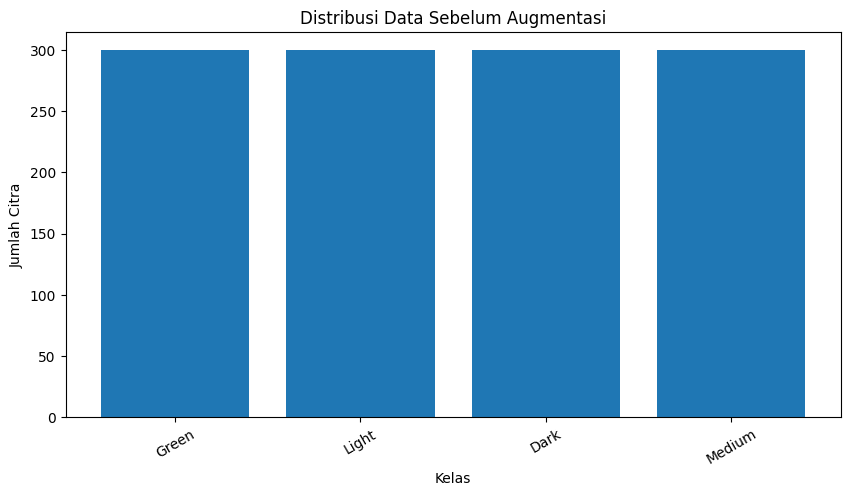

In [31]:
visualisasi_distribusi_data(
    jumlah_df,
    "Distribusi Data Sebelum Augmentasi"
)

### Visualisasi Distribusi Data

Fungsi `visualisasi_distribusi_data(jumlah_df, title)` digunakan untuk menampilkan grafik batang (*bar chart*) yang menunjukkan distribusi jumlah citra pada setiap kelas dalam dataset. Grafik dibuat menggunakan library Matplotlib dengan sumbu horizontal (x) yang merepresentasikan nama kelas dan sumbu vertikal (y) yang menunjukkan jumlah citra pada masing-masing kelas.

Pada pemanggilan fungsi `visualisasi_distribusi_data(jumlah_df, "Distribusi Data Sebelum Augmentasi")`, grafik yang dihasilkan menampilkan distribusi data sebelum dilakukan proses augmentasi. Visualisasi ini bertujuan untuk memberikan gambaran mengenai persebaran jumlah data pada setiap kategori tingkat kematangan biji kopi serta membantu mengidentifikasi apakah terdapat ketidakseimbangan jumlah data antar kelas yang berpotensi memengaruhi performa model klasifikasi.


### Menampilkan Sampel Data

Fungsi `tampilkan_sample_data()` digunakan untuk menampilkan satu sampel gambar dari setiap kelas dalam dataset. Program terlebih dahulu membaca seluruh folder kelas dan mengambil satu file gambar dari masing-masing folder yang memiliki ekstensi `.jpg`, `.jpeg`, atau `.png`.

Setiap gambar kemudian dibaca menggunakan OpenCV dan dikonversi dari format warna BGR ke RGB agar dapat ditampilkan dengan benar menggunakan Matplotlib. Selanjutnya, seluruh gambar sampel ditampilkan dalam satu figure beserta nama kelasnya, sedangkan sumbu koordinat disembunyikan agar tampilan lebih jelas.

Visualisasi ini bertujuan untuk memberikan gambaran awal mengenai karakteristik visual pada setiap kategori tingkat kematangan biji kopi serta memastikan bahwa data citra berhasil dimuat dengan baik sebelum dilakukan tahap preprocessing dan ekstraksi fitur.


In [32]:
def tampilkan_sample_data(dataset_path: str, class_names: list, figsize: tuple = (14, 5)) -> None:
    """
    Menampilkan 1 sampel gambar dari setiap kelas dalam dataset.

    Args:
        dataset_path (str)  : Path folder utama dataset
        class_names  (list) : Daftar nama kelas (nama folder)
        figsize      (tuple): Ukuran figure matplotlib, default (14, 5)
    """
    plt.figure(figsize=figsize)

    for i, class_name in enumerate(class_names):
        class_path  = os.path.join(dataset_path, class_name)
        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ]

        if len(image_files) == 0:
            print(f"[PERINGATAN] Tidak ada gambar pada kelas '{class_name}'")
            continue

        image_path = os.path.join(class_path, image_files[0])

        image     = cv.imread(image_path)
        image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

        plt.subplot(1, len(class_names), i + 1)
        plt.imshow(image_rgb)
        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("Sampel Gambar per Kelas", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


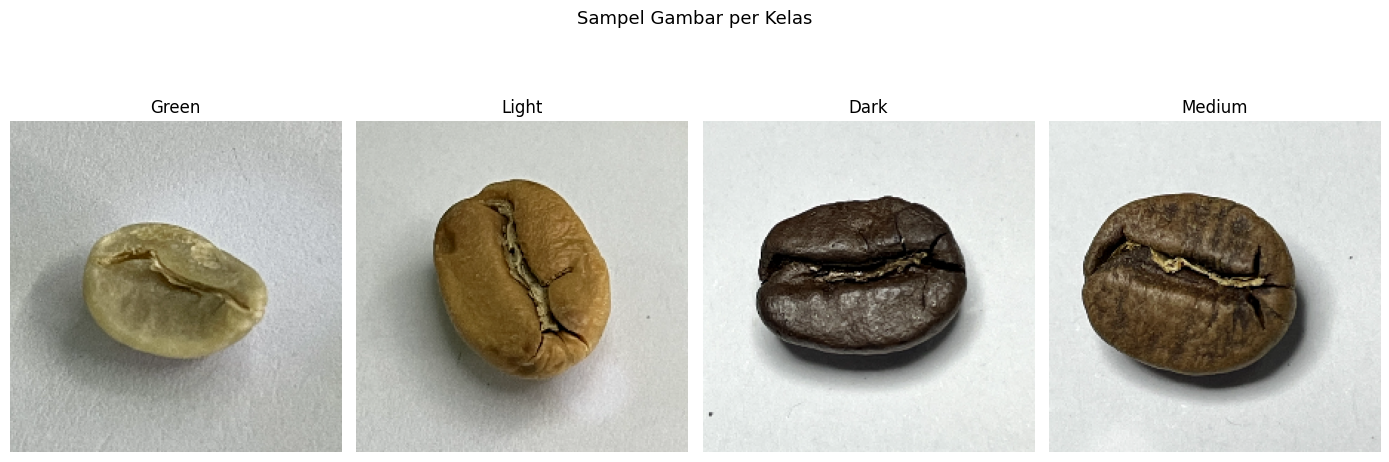

In [33]:
tampilkan_sample_data(dataset_path, class_names)

### Preprocessing Citra

Fungsi `preprocess_image()` digunakan untuk melakukan tahap awal preprocessing pada citra sebelum masuk ke proses ekstraksi fitur atau klasifikasi. Pada kode ini, preprocessing terdiri dari dua tahap utama, yaitu resize dan konversi grayscale.

Tahap pertama dilakukan oleh fungsi `prepro1()`, yaitu mengubah ukuran citra menjadi `128 × 128` piksel menggunakan metode nearest neighbor. Metode ini bekerja dengan mengambil nilai piksel terdekat dari citra asli untuk mengisi piksel pada citra baru. Resize dilakukan agar seluruh citra memiliki ukuran yang seragam sehingga lebih mudah diproses pada tahap berikutnya.

Tahap kedua dilakukan oleh fungsi `prepro2()`, yaitu mengubah citra berwarna menjadi citra grayscale. Proses ini menggunakan rumus luminance dengan memperhitungkan bobot kanal merah, hijau, dan biru. Karena citra yang dibaca menggunakan OpenCV umumnya berada dalam format BGR, maka kanal `image[:, :, 2]` digunakan sebagai merah, `image[:, :, 1]` sebagai hijau, dan `image[:, :, 0]` sebagai biru.

Hasil akhir dari fungsi `preprocess_image()` adalah citra grayscale berukuran `128 × 128` piksel. Tahap ini bertujuan untuk menyeragamkan ukuran citra dan menyederhanakan informasi warna agar data lebih siap digunakan dalam proses analisis citra.

In [34]:
def prepro1(image):
    """
    Preprocessing 1: Resize.
    Mengubah ukuran citra menjadi 128 × 128 piksel
    menggunakan metode nearest neighbor sederhana.
    """
    h, w = image.shape[:2]
    new_h, new_w = 128, 128

    resized = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            x = int(i * h / new_h)
            y = int(j * w / new_w)
            resized[i, j] = image[x, y]

    return resized


def prepro2(image):
    """
    Preprocessing 2: Grayscale.
    Mengubah citra RGB menjadi citra keabuan
    menggunakan persamaan luminance.
    """
    gray = (
        0.299 * image[:, :, 2] +
        0.587 * image[:, :, 1] +
        0.114 * image[:, :, 0]
    ).astype(np.uint8)

    return gray

In [35]:
def preprocess_image(image):
    """
    Melakukan preprocessing pada satu gambar untuk Percobaan 3.

    Tahapan:
        1. Resize
        2. Grayscale

    """
    image = prepro1(image)  # Resize
    image = prepro2(image)  # Grayscale

    return image

In [36]:
data_preprocessed = [preprocess_image(img) for img in data]

print(f"Preprocessing selesai.")
print(f"Jumlah gambar : {len(data_preprocessed)}")
print(f"Ukuran output : {data_preprocessed[0].shape}  → (tinggi, lebar)")

Preprocessing selesai.
Jumlah gambar : 1200
Ukuran output : (128, 128)  → (tinggi, lebar)


### Menjalankan Preprocessing pada Seluruh Data

Kode `data_preprocessed = [preprocess_image(img) for img in data]` digunakan untuk menerapkan fungsi preprocessing ke seluruh gambar yang ada di dalam variabel `data`. Setiap gambar akan diproses satu per satu melalui fungsi `preprocess_image()`, sehingga seluruh citra mengalami tahapan resize dan konversi grayscale.

Hasil dari proses tersebut disimpan dalam variabel `data_preprocessed` dalam bentuk list. Dengan demikian, `data_preprocessed` berisi kumpulan gambar yang sudah memiliki format seragam, yaitu citra grayscale berukuran `128 × 128` piksel.

Bagian `print()` digunakan untuk menampilkan informasi hasil preprocessing. Program akan mencetak bahwa proses preprocessing telah selesai, jumlah gambar yang berhasil diproses, serta ukuran output dari gambar pertama. Informasi ukuran output ditampilkan untuk memastikan bahwa hasil preprocessing sudah sesuai, yaitu berbentuk `(tinggi, lebar)`.

### Menampilkan Perbandingan Citra Original dan Hasil Preprocessing

Kode ini digunakan untuk menampilkan perbandingan antara citra asli dan citra hasil preprocessing dari setiap kelas dalam dataset. Program terlebih dahulu membuat figure berukuran `8 × 8`, kemudian melakukan perulangan berdasarkan daftar kelas yang terdapat pada variabel `class_names`.

Pada setiap kelas, program mengambil folder kelas menggunakan `os.path.join()`, lalu memilih file gambar pertama yang memiliki ekstensi `.jpg`, `.jpeg`, atau `.png`. Gambar tersebut kemudian dibaca menggunakan `cv.imread()` dan diproses menggunakan fungsi `preprocess_image()`, sehingga menghasilkan citra yang sudah melalui tahap resize dan grayscale.

Hasil visualisasi ditampilkan dalam bentuk subplot dengan dua kolom. Kolom pertama menampilkan gambar asli dalam format RGB, sedangkan kolom kedua menampilkan hasil preprocessing berupa citra grayscale yang telah di-resize. Visualisasi ini bertujuan untuk melihat perbedaan antara citra awal dan citra setelah preprocessing, sekaligus memastikan bahwa proses grayscale dan resize berhasil diterapkan dengan benar pada setiap kelas.


### Analisis Hasil Preprocessing

Berdasarkan hasil visualisasi, proses preprocessing berhasil diterapkan pada citra biji kopi untuk klasifikasi tingkat kematangan, yaitu kelas `Green`, `Light`, `Medium`, dan `Dark`. Setiap citra original diubah melalui dua tahap, yaitu resize dan grayscale. Tahap resize membuat seluruh gambar memiliki ukuran yang seragam, sedangkan tahap grayscale mengubah citra berwarna menjadi citra keabuan.

Hasil preprocessing menunjukkan bahwa bentuk biji kopi, tekstur permukaan, garis tengah biji, serta perbedaan intensitas gelap dan terang masih dapat terlihat dengan cukup jelas. Informasi tersebut penting karena dapat membantu model mengenali karakteristik visual dari setiap tingkat kematangan biji kopi.

Namun, penggunaan grayscale juga memiliki kelemahan karena warna asli biji kopi dihilangkan. Padahal, warna merupakan salah satu ciri utama dalam membedakan tingkat kematangan biji kopi, terutama antara kelas `Green`, `Light`, dan `Medium`. Setelah diubah menjadi grayscale, beberapa kelas terlihat lebih mirip karena perbedaan warna tidak lagi terlihat secara langsung.

Secara keseluruhan, preprocessing resize dan grayscale sudah sesuai untuk menyeragamkan data citra sebelum klasifikasi. Akan tetapi, karena klasifikasi tingkat kematangan biji kopi sangat dipengaruhi oleh warna, penggunaan grayscale saja dapat mengurangi informasi penting yang berpotensi memengaruhi akurasi model.

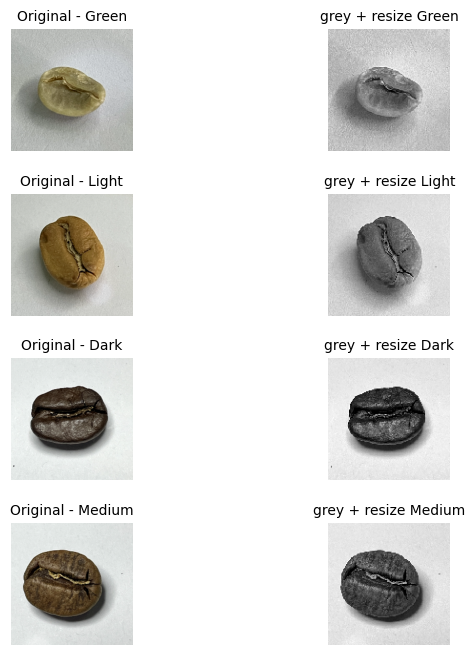

In [37]:
plt.figure(figsize=(8, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(class_path, image_files[0])

    image = cv.imread(image_path)
    processed = preprocess_image(image)

    plt.subplot(len(class_names), 2, (i * 2) + 1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(f"Original - {class_name}", fontsize=10)
    plt.axis("off")

    plt.subplot(len(class_names), 2, (i * 2) + 2)
    plt.imshow(processed, cmap="gray")
    plt.title(f"grey + resize {class_name}", fontsize=10)
    plt.axis("off")

plt.subplots_adjust(wspace=0.05, hspace=0.35)
plt.show()

In [38]:

DISTANCES   = [1, 2, 3, 4, 5]
ANGLES      = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_NAMES = ["0", "45", "90", "135"]
PROPERTIES  = [
    "contrast", "dissimilarity", "homogeneity",
    "energy", "correlation", "ASM"
]


def extract_glcm_features(image: np.ndarray) -> dict:
    """
    Ekstraksi fitur tekstur GLCM dari satu gambar grayscale.

    Menggunakan 5 jarak (1–5), 4 sudut (0°/45°/90°/135°),
    dan 7 properti: contrast, dissimilarity, homogeneity,
    energy, correlation, ASM, dan entropy (manual).

    Args:
        image (np.ndarray): Gambar grayscale 2D hasil preprocessing

    Returns:
        dict: 140 fitur dengan nama format {properti}_d{jarak}_a{sudut}
    """
    glcm = graycomatrix(
        image,
        distances=DISTANCES,
        angles=ANGLES,
        levels=256,
        symmetric=True,
        normed=True
    )

    features = {}

    for prop in PROPERTIES:
        values = graycoprops(glcm, prop)
        for d_idx, dist in enumerate(DISTANCES):
            for a_idx, angle in enumerate(ANGLE_NAMES):
                features[f"{prop}_d{dist}_a{angle}"] = values[d_idx, a_idx]

    # Entropy dihitung manual (tidak tersedia di graycoprops)
    for d_idx, dist in enumerate(DISTANCES):
        for a_idx, angle in enumerate(ANGLE_NAMES):
            matrix = glcm[:, :, d_idx, a_idx]
            features[f"entropy_d{dist}_a{angle}"] = (
                -np.sum(matrix * np.log2(matrix + 1e-10))
            )

    return features

### Ekstraksi Fitur GLCM

Kode ini digunakan untuk mengekstraksi fitur tekstur dari citra grayscale menggunakan metode **GLCM** atau *Gray Level Co-occurrence Matrix*. GLCM bekerja dengan menghitung hubungan kemunculan pasangan piksel berdasarkan jarak dan arah tertentu. Pada kode ini, jarak yang digunakan adalah `1, 2, 3, 4, 5`, sedangkan sudut yang digunakan adalah `0°`, `45°`, `90°`, dan `135°`.

Fungsi `extract_glcm_features()` menerima input berupa citra grayscale hasil preprocessing. Citra tersebut kemudian diproses menggunakan `graycomatrix()` dengan `levels=256`, sehingga nilai intensitas piksel dianggap berada pada rentang `0–255`. Parameter `symmetric=True` membuat hubungan antar piksel dihitung secara dua arah, sedangkan `normed=True` membuat nilai matriks dinormalisasi agar berbentuk probabilitas.

Setelah matriks GLCM terbentuk, kode menghitung beberapa fitur tekstur menggunakan `graycoprops()`, yaitu `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `ASM`. Setiap fitur dihitung untuk semua kombinasi jarak dan sudut, lalu disimpan ke dalam dictionary dengan format nama seperti `contrast_d1_a0`, `homogeneity_d3_a90`, dan seterusnya.

Selain fitur dari `graycoprops()`, kode juga menghitung fitur `entropy` secara manual karena entropy tidak tersedia langsung pada fungsi tersebut. Entropy digunakan untuk mengukur tingkat ketidakteraturan tekstur pada citra. Semakin tinggi nilai entropy, semakin kompleks atau tidak beraturan tekstur citra tersebut.

Secara keseluruhan, fungsi ini menghasilkan `140 fitur`, yang berasal dari `7 properti × 5 jarak × 4 sudut`. Fitur-fitur ini kemudian dapat digunakan sebagai data numerik untuk proses klasifikasi tingkat kematangan biji kopi.

### Ekstraksi Fitur GLCM

Kode ini digunakan untuk melakukan ekstraksi fitur tekstur pada seluruh citra hasil preprocessing. Setiap gambar yang tersimpan dalam `data_preprocessed` diproses menggunakan fungsi `extract_glcm_features()` untuk menghasilkan fitur GLCM berdasarkan variasi jarak dan sudut tertentu.

Pada setiap perulangan, fitur yang telah diperoleh kemudian ditambahkan dengan informasi `Label` dan `Filename`. Kolom `Label` digunakan untuk menunjukkan kelas tingkat kematangan biji kopi, seperti `Green`, `Light`, `Medium`, dan `Dark`, sedangkan kolom `Filename` digunakan untuk menyimpan nama file gambar asal agar data tetap dapat dilacak.

Hasil ekstraksi fitur disimpan dalam list `hasil_fitur`, kemudian diubah menjadi DataFrame menggunakan `pd.DataFrame()`. Berdasarkan output, setiap baris merepresentasikan satu gambar, sedangkan setiap kolom merepresentasikan fitur tekstur yang dihasilkan, seperti `contrast` dan `entropy` pada beberapa jarak serta sudut. Total terdapat `142` kolom, yang terdiri dari fitur GLCM serta kolom tambahan `Label` dan `Filename`.

Secara umum, hasil ini menunjukkan bahwa citra biji kopi telah berhasil diubah dari bentuk gambar menjadi data numerik. Data numerik inilah yang nantinya digunakan sebagai input pada proses klasifikasi tingkat kematangan biji kopi.

In [39]:
hasil_fitur = []

for i in range(len(data_preprocessed)):
    features = extract_glcm_features(data_preprocessed[i])

    features["Label"] = labels[i]
    features["Filename"] = file_names[i]

    hasil_fitur.append(features)

hasil_ekstrak = pd.DataFrame(hasil_fitur)

hasil_ekstrak.head()

,contrast_d1_a0,contrast_d1_a45,contrast_d1_a90,contrast_d1_a135,contrast_d2_a0,contrast_d2_a45,contrast_d2_a90,contrast_d2_a135,contrast_d3_a0,contrast_d3_a45,...,entropy_d4_a0,entropy_d4_a45,entropy_d4_a90,entropy_d4_a135,entropy_d5_a0,entropy_d5_a45,entropy_d5_a90,entropy_d5_a135,Label,Filename
0,142.450418,172.833158,162.929380,200.933846,187.463356,172.833158,243.167535,200.933846,227.678312,240.974427,...,12.079089,12.146991,12.134625,12.155928,12.137756,12.220783,12.199643,12.236180,Green,green (156).png
1,244.776390,347.466737,309.597749,349.994420,334.743242,347.466737,425.997396,349.994420,414.282438,474.848199,...,11.878590,11.963241,11.965004,11.953213,11.931055,12.066758,12.039859,12.051091,Green,green (82).png
2,190.683809,210.631099,142.960199,255.650939,338.337054,210.631099,248.392299,255.650939,450.335688,364.489292,...,12.335723,12.287115,12.186465,12.346720,12.412628,12.387496,12.251867,12.450679,Green,green (136).png
3,157.695682,246.570463,187.913201,256.222642,256.588356,246.570463,372.289063,256.222642,329.761562,424.386432,...,12.129077,12.221505,12.203586,12.219173,12.194212,12.307288,12.263159,12.305784,Green,green (227).png
4,323.058071,441.035154,412.277867,468.873520,450.934276,441.035154,520.618180,468.873520,549.520813,590.995465,...,11.760067,11.788482,11.753159,11.835929,11.841147,11.894785,11.825643,11.961649,Green,green (122).png


In [40]:
print("Jumlah data:", hasil_ekstrak.shape[0])
print("Jumlah kolom:", hasil_ekstrak.shape[1])

Jumlah data: 1200
Jumlah kolom: 142


### Mengecek Jumlah Data dan Kolom

Kode ini digunakan untuk menampilkan ukuran dari DataFrame `hasil_ekstrak` setelah proses ekstraksi fitur selesai dilakukan. Perintah `hasil_ekstrak.shape[0]` digunakan untuk menghitung jumlah baris data, sedangkan `hasil_ekstrak.shape[1]` digunakan untuk menghitung jumlah kolom.

Berdasarkan output, terdapat `1200` data citra yang berhasil diproses dan diekstraksi fiturnya. Setiap baris pada DataFrame merepresentasikan satu gambar biji kopi yang telah melalui tahap preprocessing dan ekstraksi fitur GLCM.

Jumlah kolom sebanyak `142` menunjukkan bahwa setiap citra memiliki banyak fitur numerik hasil ekstraksi, ditambah dengan kolom `Label` dan `Filename`. Data ini kemudian dapat digunakan sebagai dataset untuk proses klasifikasi tingkat kematangan biji kopi.

### Seleksi Fitur Berdasarkan Korelasi

Kode ini digunakan untuk melakukan seleksi fitur pada hasil ekstraksi GLCM. Kolom `Label` dan `Filename` terlebih dahulu dihapus karena keduanya bukan termasuk fitur numerik yang digunakan untuk proses klasifikasi. Setelah itu, program menghitung nilai korelasi antarfitur menggunakan `fitur.corr().abs()`.

Nilai korelasi yang digunakan adalah nilai absolut, sehingga hubungan positif maupun negatif yang sangat kuat tetap dianggap sebagai korelasi tinggi. Program kemudian mengambil bagian segitiga atas dari matriks korelasi menggunakan `np.triu()` agar pasangan fitur yang sama tidak dihitung dua kali.

Fitur yang memiliki korelasi lebih dari `0.95` akan dimasukkan ke dalam daftar `to_drop`. Artinya, fitur tersebut dianggap terlalu mirip atau redundan dengan fitur lain. Berdasarkan hasil output, jumlah fitur awal adalah `140`, kemudian sebanyak `121` fitur dihapus karena memiliki korelasi tinggi, sehingga tersisa `19` fitur terpilih.

Hasil `fitur_selected.head()` menunjukkan beberapa fitur yang dipertahankan, seperti `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `entropy` pada jarak serta sudut tertentu. Seleksi ini bertujuan untuk mengurangi fitur yang berlebihan agar proses klasifikasi menjadi lebih sederhana, efisien, dan tidak terlalu dipengaruhi oleh fitur yang memiliki informasi serupa.

In [41]:
fitur = hasil_ekstrak.drop(columns=["Label", "Filename"])

correlation = fitur.corr().abs()

upper = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Jumlah fitur sebelum seleksi:", fitur.shape[1])
print("Jumlah fitur yang dihapus:", len(to_drop))

fitur_selected = fitur.drop(columns=to_drop)

print("Jumlah fitur setelah seleksi:", fitur_selected.shape[1])

Jumlah fitur sebelum seleksi: 140
Jumlah fitur yang dihapus: 121
Jumlah fitur setelah seleksi: 19


### Analisis Hasil Seleksi Fitur

Berdasarkan hasil output `fitur_selected.head()`, dapat dilihat bahwa DataFrame menampilkan lima data pertama dari fitur yang telah melalui proses seleksi berdasarkan korelasi. Sebelum seleksi dilakukan, jumlah fitur numerik hasil ekstraksi GLCM adalah `140` fitur. Setelah dilakukan pengecekan korelasi antarfitur dengan batas korelasi lebih dari `0.95`, sebanyak `121` fitur dihapus karena dianggap memiliki hubungan yang sangat kuat dengan fitur lain. Dengan demikian, fitur yang tersisa hanya berjumlah `19` fitur.

Pengurangan jumlah fitur ini menunjukkan bahwa sebagian besar fitur GLCM memiliki informasi yang saling mirip atau redundan. Hal ini wajar terjadi karena fitur GLCM dihitung menggunakan beberapa kombinasi jarak dan sudut. Misalnya, fitur `contrast`, `dissimilarity`, atau `entropy` pada sudut dan jarak tertentu dapat memiliki pola nilai yang hampir sama dengan fitur pada sudut atau jarak lainnya. Jika semua fitur tersebut tetap digunakan, model klasifikasi dapat menjadi terlalu kompleks dan berisiko mempelajari informasi yang berulang.

Fitur yang dipertahankan terdiri dari beberapa jenis fitur tekstur, yaitu `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, dan `entropy`. Fitur `contrast` digunakan untuk mengukur tingkat perbedaan intensitas antar piksel. Pada output terlihat bahwa nilai `contrast` memiliki variasi yang cukup besar, misalnya pada data indeks ke-0 nilai `contrast_d1_a0` sebesar `142.45`, sedangkan pada data indeks ke-4 nilainya mencapai `323.06`. Perbedaan ini menunjukkan bahwa tekstur pada setiap citra biji kopi memiliki tingkat variasi gelap-terang yang berbeda.

Fitur `dissimilarity` juga menunjukkan perbedaan intensitas antar piksel, tetapi dengan perhitungan yang lebih sederhana dibandingkan `contrast`. Pada tabel, nilai `dissimilarity` berada pada rentang sekitar `8` hingga `13`. Semakin tinggi nilai `dissimilarity`, semakin besar perbedaan tekstur pada citra. Hal ini penting dalam klasifikasi tingkat kematangan biji kopi karena setiap tingkat kematangan dapat memiliki pola permukaan yang berbeda, baik dari segi kecerahan, tekstur kulit biji, maupun garis tengah biji kopi.

Fitur `homogeneity_d1_a0` memiliki nilai yang relatif kecil, yaitu sekitar `0.11` sampai `0.15`. Nilai ini menunjukkan bahwa citra biji kopi tidak memiliki tekstur yang sepenuhnya seragam. Semakin tinggi nilai homogeneity, semakin halus atau seragam tekstur citra. Sebaliknya, nilai yang rendah menunjukkan adanya variasi tekstur. Pada kasus biji kopi, variasi ini dapat muncul karena perbedaan permukaan biji, bayangan, lekukan, dan tingkat kematangan.

Fitur `energy_d1_a0` juga memiliki nilai yang kecil, yaitu sekitar `0.019` sampai `0.035`. Energy menggambarkan tingkat keteraturan pola tekstur pada citra. Nilai energy yang kecil menunjukkan bahwa pola tekstur pada citra cukup kompleks dan tidak terlalu berulang secara teratur. Kondisi ini sesuai dengan karakteristik citra biji kopi, karena permukaan biji memiliki bentuk, pencahayaan, dan tekstur yang tidak selalu sama pada setiap gambar.

Fitur `correlation` memiliki nilai yang cukup tinggi, yaitu berada pada kisaran `0.91` sampai `0.96`. Nilai ini menunjukkan bahwa terdapat hubungan yang kuat antar piksel yang berdekatan pada citra. Artinya, pola intensitas pada citra biji kopi masih memiliki keterkaitan spasial yang jelas. Fitur ini dapat membantu model mengenali pola struktur tekstur pada setiap kelas kematangan biji kopi.

Fitur `entropy_d1_a0` memiliki nilai sekitar `11.43` sampai `11.95`. Entropy digunakan untuk mengukur tingkat kompleksitas atau ketidakteraturan tekstur citra. Nilai entropy yang cukup tinggi menunjukkan bahwa citra biji kopi memiliki pola tekstur yang bervariasi. Fitur ini penting karena tingkat kematangan biji kopi tidak hanya dapat dibedakan dari warna, tetapi juga dari perbedaan tekstur dan pola permukaan.

Secara keseluruhan, hasil seleksi fitur menunjukkan bahwa proses reduksi fitur berhasil menyederhanakan data dari `140` fitur menjadi `19` fitur tanpa menghilangkan jenis informasi tekstur utama. Fitur yang tersisa masih mewakili karakteristik penting citra, seperti perbedaan intensitas, keseragaman tekstur, keteraturan pola, hubungan antar piksel, dan kompleksitas permukaan biji kopi. Dengan jumlah fitur yang lebih sedikit, proses klasifikasi diharapkan menjadi lebih efisien, lebih ringan, dan tidak terlalu dipengaruhi oleh fitur yang memiliki informasi berulang.


In [42]:
fitur_selected.head()

,contrast_d1_a0,contrast_d1_a45,contrast_d1_a90,contrast_d1_a135,dissimilarity_d1_a0,dissimilarity_d1_a45,dissimilarity_d1_a90,dissimilarity_d1_a135,dissimilarity_d2_a0,dissimilarity_d2_a90,dissimilarity_d3_a45,dissimilarity_d3_a135,homogeneity_d1_a0,energy_d1_a0,correlation_d1_a0,correlation_d1_a45,correlation_d1_a90,correlation_d1_a135,entropy_d1_a0
0,142.450418,172.833158,162.929380,200.933846,8.731545,9.273731,8.584646,9.634323,9.606337,10.298487,10.598513,10.982489,0.117614,0.019929,0.941116,0.928940,0.932646,0.917388,11.891876
1,244.776390,347.466737,309.597749,349.994420,9.007443,10.575671,9.757812,10.444293,10.455295,11.552083,12.412824,12.497543,0.145223,0.026753,0.947215,0.925466,0.933345,0.924924,11.652723
2,190.683809,210.631099,142.960199,255.650939,8.838337,9.256061,8.026144,10.066340,11.153026,9.818762,11.501134,12.633031,0.126388,0.021560,0.958031,0.953820,0.968516,0.943951,11.951119
3,157.695682,246.570463,187.913201,256.222642,8.873708,10.224254,8.628875,10.335483,10.501550,11.604911,12.589380,12.723860,0.121839,0.022447,0.962427,0.941489,0.955214,0.939198,11.919393
4,323.058071,441.035154,412.277867,468.873520,9.681718,11.193502,10.672675,11.636741,11.476438,12.409350,13.261653,13.778219,0.155593,0.035960,0.939607,0.917867,0.922961,0.912684,11.434308


In [43]:
X = fitur_selected
y = hasil_ekstrak["Label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 19)
X_test: (240, 19)
y_train: (960,)
y_test: (240,)


### Pembagian Data Training dan Testing

Kode ini digunakan untuk membagi data menjadi fitur (`X`) dan label (`y`). Variabel `X` berisi fitur hasil seleksi, sedangkan `y` berisi label tingkat kematangan biji kopi.

Label yang masih berbentuk teks kemudian diubah menjadi angka menggunakan `LabelEncoder()` agar dapat diproses oleh model machine learning. Setelah itu, data dibagi menjadi data training dan testing menggunakan `train_test_split()` dengan perbandingan 80% data training dan 20% data testing.

Parameter `stratify=y_encoded` digunakan agar proporsi setiap kelas tetap seimbang pada data training dan testing. Berdasarkan output, terdapat `960` data training dan `240` data testing, dengan masing-masing data memiliki `19` fitur.


In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalisasi selesai")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Normalisasi selesai
X_train_scaled: (960, 19)
X_test_scaled: (240, 19)


### Normalisasi Fitur

Kode ini digunakan untuk melakukan normalisasi fitur menggunakan `StandardScaler()`. Normalisasi dilakukan agar setiap fitur memiliki skala yang seimbang, sehingga model tidak terlalu dipengaruhi oleh fitur yang memiliki nilai lebih besar.

Pada data training, digunakan `fit_transform()` karena scaler perlu menghitung nilai rata-rata dan standar deviasi dari `X_train`, lalu langsung menerapkannya. Sementara itu, pada data testing digunakan `transform()` agar data uji mengikuti skala yang sama berdasarkan data training.

Berdasarkan output, proses normalisasi berhasil dilakukan. Ukuran `X_train_scaled` tetap `(960, 19)` dan `X_test_scaled` tetap `(240, 19)`, artinya jumlah data dan fitur tidak berubah, hanya nilai fiturnya yang dinormalisasi.


In [45]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel="rbf", C=10, gamma="scale")
rf = RandomForestClassifier(n_estimators=100, random_state=42)

knn.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

### Pelatihan Model Klasifikasi

Kode ini digunakan untuk membuat dan melatih tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Model KNN menggunakan `n_neighbors=5`, artinya prediksi kelas ditentukan berdasarkan 5 data terdekat. Model SVM menggunakan kernel `rbf` untuk memisahkan data secara non-linear, sedangkan Random Forest menggunakan `100` pohon keputusan dengan `random_state=42` agar hasil tetap konsisten.

Setelah model dibuat, masing-masing model dilatih menggunakan `X_train_scaled` dan `y_train`. Data fitur yang digunakan sudah melalui proses normalisasi, sehingga lebih sesuai untuk model seperti KNN dan SVM yang sensitif terhadap skala fitur.

Selanjutnya, setiap model digunakan untuk memprediksi data testing melalui fungsi `predict()`. Hasil prediksi disimpan dalam variabel `y_pred_knn`, `y_pred_svm`, dan `y_pred_rf`. Hasil prediksi ini nantinya dapat digunakan untuk mengevaluasi performa model dalam mengklasifikasikan tingkat kematangan biji kopi.


### Evaluasi Model Klasifikasi

Kode ini digunakan untuk mengevaluasi performa tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Evaluasi dilakukan dengan membandingkan label asli pada `y_test` dengan hasil prediksi masing-masing model, yaitu `y_pred_knn`, `y_pred_svm`, dan `y_pred_rf`.

Metrik yang digunakan meliputi `Accuracy`, `Precision`, `Recall`, dan `F1-Score`. Accuracy menunjukkan tingkat ketepatan prediksi secara keseluruhan. Precision menunjukkan seberapa tepat model dalam memprediksi suatu kelas, sedangkan recall menunjukkan kemampuan model dalam menemukan data dari setiap kelas. F1-Score merupakan gabungan antara precision dan recall.

Parameter `average="weighted"` digunakan karena klasifikasi memiliki lebih dari dua kelas. Dengan parameter ini, nilai precision, recall, dan F1-Score dihitung berdasarkan proporsi jumlah data pada setiap kelas. Hasil evaluasi kemudian disimpan dalam DataFrame `hasil_evaluasi` agar perbandingan performa antar model lebih mudah dibaca.


### Analisis Hasil Evaluasi Model

Berdasarkan hasil evaluasi, model SVM memperoleh performa terbaik dengan accuracy sebesar `0.8708`, precision sebesar `0.8713`, recall sebesar `0.8708`, dan F1-Score sebesar `0.8710`. Hasil ini menunjukkan bahwa SVM mampu mengklasifikasikan tingkat kematangan biji kopi dengan lebih baik dibandingkan KNN dan Random Forest. Random Forest berada pada posisi kedua dengan accuracy sebesar `0.8042`, sedangkan KNN memperoleh hasil terendah dengan accuracy sebesar `0.7250`.

Perbedaan performa tersebut berkaitan dengan tahapan preprocessing yang digunakan, yaitu resize dan grayscale. Pada Preprocessing 1, citra diubah ukurannya menjadi `128 × 128` piksel. Tahap resize ini penting karena setiap gambar dalam dataset perlu memiliki ukuran yang sama sebelum diekstraksi fiturnya. Jika ukuran gambar berbeda-beda, proses ekstraksi fitur GLCM dapat menghasilkan pola fitur yang tidak konsisten. Dengan ukuran yang seragam, setiap citra memiliki dimensi yang sama sehingga fitur tekstur dapat dibandingkan secara lebih adil antar kelas.

Pada Preprocessing 2, citra RGB diubah menjadi grayscale. Tahap ini membuat gambar tidak lagi menggunakan informasi warna, melainkan hanya menggunakan nilai intensitas keabuan. Hal ini memiliki pengaruh besar terhadap hasil klasifikasi karena tingkat kematangan biji kopi sebenarnya sangat berkaitan dengan warna, misalnya perbedaan antara `Green`, `Light`, `Medium`, dan `Dark`. Setelah citra diubah menjadi grayscale, informasi warna asli menjadi hilang, sehingga model hanya bergantung pada perbedaan tekstur, bentuk, bayangan, dan intensitas gelap-terang.

Kondisi tersebut menjelaskan mengapa hasil klasifikasi belum mencapai nilai yang sangat tinggi pada semua model. Kelas yang memiliki warna berbeda tetapi teksturnya mirip, seperti `Green` dan `Light`, berpotensi lebih sulit dibedakan setelah proses grayscale. Sebaliknya, kelas seperti `Medium` dan `Dark` masih dapat dibedakan dengan lebih baik karena biasanya memiliki perbedaan intensitas keabuan dan tekstur permukaan yang lebih jelas.

Model KNN memperoleh nilai terendah karena algoritma ini sangat bergantung pada jarak antar data. Jika fitur tekstur antar kelas saling berdekatan akibat hilangnya informasi warna, maka KNN dapat lebih mudah salah dalam menentukan kelas tetangga terdekat. Random Forest memiliki hasil yang lebih baik karena mampu mempelajari pola dari banyak fitur secara lebih fleksibel. Namun, SVM memberikan hasil terbaik karena kernel `rbf` mampu memisahkan pola data yang tidak linear, sehingga lebih sesuai untuk fitur tekstur hasil GLCM yang berasal dari citra grayscale.

Secara keseluruhan, preprocessing resize dan grayscale berhasil menyiapkan data citra agar dapat diproses oleh model klasifikasi. Resize membantu menyeragamkan ukuran citra, sedangkan grayscale menyederhanakan citra menjadi informasi intensitas. Namun, karena grayscale menghilangkan informasi warna, hasil klasifikasi sangat bergantung pada fitur tekstur GLCM. Hal ini menjadi alasan mengapa SVM lebih unggul, karena model tersebut lebih mampu menangkap pola perbedaan tekstur dan intensitas dibandingkan KNN dan Random Forest pada dataset ini.


In [46]:
hasil_evaluasi = pd.DataFrame([
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn, average="weighted"),
        "Recall": recall_score(y_test, y_pred_knn, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_knn, average="weighted")
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average="weighted"),
        "Recall": recall_score(y_test, y_pred_svm, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_svm, average="weighted")
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average="weighted"),
        "Recall": recall_score(y_test, y_pred_rf, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred_rf, average="weighted")
    }
])

hasil_evaluasi

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.725000,0.728184,0.725000,0.724555
1,SVM,0.870833,0.871325,0.870833,0.870956
2,Random Forest,0.804167,0.807630,0.804167,0.804656


### Visualisasi Confusion Matrix

Kode ini digunakan untuk menampilkan confusion matrix dari tiga model klasifikasi, yaitu KNN, SVM, dan Random Forest. Variabel `models_pred` menyimpan nama model beserta hasil prediksinya masing-masing. Selanjutnya, program membuat figure berukuran `16 × 5` agar ketiga confusion matrix dapat ditampilkan dalam satu baris.

Pada setiap perulangan, fungsi `confusion_matrix(y_test, y_pred)` digunakan untuk menghitung jumlah prediksi benar dan salah dari setiap kelas. Hasil confusion matrix kemudian ditampilkan menggunakan `plt.imshow()` dengan warna biru. Label pada sumbu X menunjukkan kelas hasil prediksi, sedangkan label pada sumbu Y menunjukkan kelas sebenarnya.

Bagian `plt.xticks()` dan `plt.yticks()` digunakan untuk menampilkan nama kelas berdasarkan `label_encoder.classes_`, yaitu `Dark`, `Green`, `Light`, dan `Medium`. Setiap nilai pada kotak confusion matrix ditampilkan menggunakan `plt.text()` agar jumlah data pada setiap kombinasi kelas dapat terlihat dengan jelas.



### Analisis Hasil Confusion Matrix

Berdasarkan hasil visualisasi, nilai pada diagonal utama menunjukkan jumlah data yang berhasil diklasifikasikan dengan benar oleh model. Semakin besar nilai pada diagonal utama, semakin baik kemampuan model dalam mengenali kelas tersebut. Sebaliknya, nilai di luar diagonal menunjukkan kesalahan prediksi, yaitu data dari kelas tertentu yang diprediksi sebagai kelas lain.

Pada model KNN, jumlah prediksi benar untuk kelas `Dark` adalah `42`, `Green` sebanyak `52`, `Light` sebanyak `42`, dan `Medium` sebanyak `38`. Model ini masih cukup banyak melakukan kesalahan, terutama pada kelas `Dark` yang diprediksi sebagai `Medium` sebanyak `17` data dan kelas `Medium` yang diprediksi sebagai `Dark` sebanyak `22` data. Hal ini menunjukkan bahwa KNN kesulitan membedakan kelas `Dark` dan `Medium`, kemungkinan karena kedua kelas memiliki kemiripan tekstur dan intensitas keabuan setelah proses grayscale.

Pada model SVM, hasil klasifikasi terlihat paling baik dibandingkan model lainnya. Kelas `Dark` berhasil dikenali dengan benar sebanyak `53` data, `Green` sebanyak `53` data, `Light` sebanyak `52` data, dan `Medium` sebanyak `51` data. Kesalahan prediksi pada SVM relatif lebih sedikit dan lebih tersebar. Misalnya, kelas `Dark` hanya salah diprediksi sebagai `Medium` sebanyak `7` data, sedangkan kelas `Medium` salah diprediksi sebagai `Dark` sebanyak `8` data. Hasil ini menunjukkan bahwa SVM lebih mampu memisahkan pola fitur antar kelas, terutama pada data tekstur hasil GLCM.

Pada model Random Forest, jumlah prediksi benar untuk kelas `Dark` adalah `46`, `Green` sebanyak `48`, `Light` sebanyak `51`, dan `Medium` sebanyak `48`. Model ini memiliki performa lebih baik daripada KNN, tetapi masih belum sebaik SVM. Kesalahan yang cukup terlihat adalah kelas `Dark` diprediksi sebagai `Medium` sebanyak `13` data, kelas `Green` diprediksi sebagai `Light` sebanyak `12` data, dan kelas `Medium` diprediksi sebagai `Dark` sebanyak `11` data. Hal ini menunjukkan bahwa Random Forest masih mengalami kesulitan pada kelas yang memiliki karakteristik visual berdekatan.

Secara umum, confusion matrix menunjukkan bahwa kesalahan prediksi paling sering terjadi pada pasangan kelas `Dark` dengan `Medium` serta `Green` dengan `Light`. Hal ini berkaitan dengan tahapan preprocessing yang digunakan, yaitu resize dan grayscale. Proses resize membantu menyeragamkan ukuran citra, tetapi proses grayscale menghilangkan informasi warna asli biji kopi. Akibatnya, model tidak lagi menggunakan warna sebagai pembeda utama, melainkan hanya mengandalkan tekstur, bentuk, dan intensitas gelap-terang.

Dalam klasifikasi tingkat kematangan biji kopi, warna sebenarnya merupakan ciri penting. Kelas `Green` dan `Light` dapat menjadi lebih sulit dibedakan setelah citra diubah menjadi grayscale karena perbedaan warna hijau dan cokelat muda tidak lagi terlihat secara langsung. Begitu juga dengan kelas `Dark` dan `Medium`, yang sama-sama memiliki intensitas gelap sehingga lebih mudah tertukar.

Berdasarkan visualisasi ini, model SVM menjadi model terbaik karena memiliki jumlah prediksi benar paling tinggi dan kesalahan prediksi paling sedikit. Hasil ini sesuai dengan evaluasi sebelumnya, yaitu SVM memperoleh accuracy, precision, recall, dan F1-Score tertinggi dibandingkan KNN dan Random Forest. Dengan demikian, pada percobaan klasifikasi tingkat kematangan biji kopi menggunakan preprocessing resize, grayscale, dan fitur GLCM, model SVM memberikan performa paling optimal.


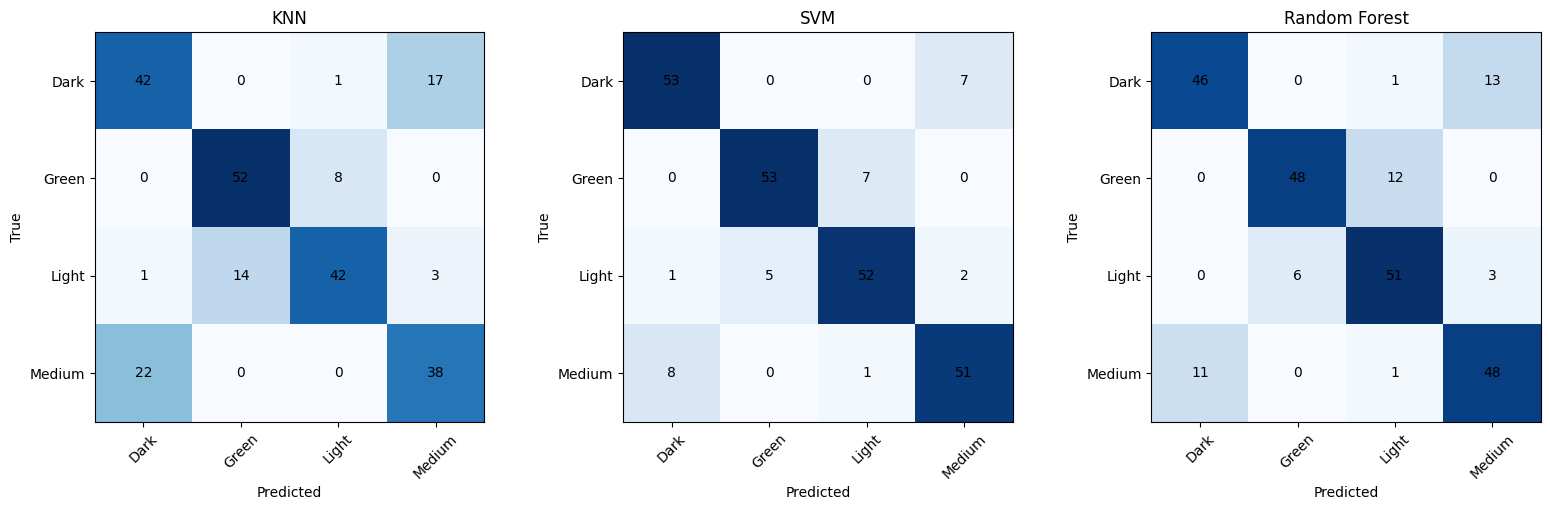

In [47]:
models_pred = {
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

plt.figure(figsize=(16, 5))

for i, (model_name, y_pred) in enumerate(models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i + 1)
    plt.imshow(cm, cmap="Blues")
    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.xticks(
        ticks=np.arange(len(label_encoder.classes_)),
        labels=label_encoder.classes_,
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(label_encoder.classes_)),
        labels=label_encoder.classes_
    )

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(
                col,
                row,
                cm[row, col],
                ha="center",
                va="center",
                color="black"
            )

plt.tight_layout()
plt.show()
